In [31]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

GENERE UN MODELO DE REGRESIÓN LINEAL Y ESTE MODELO SE TIENE QUE CONSEGUIR LOS COEFICIENTES DEL MODELO (BETAS) DEBIDO A QUE LA MUESTRA ES MUY PEQUEÑA NO DIVIDIR EL DATASET EN DOS, ADICIONALMENTE PUEDE INCLUIR UN EDA COMPLETO Y MOSTRAR LA RECTA DE REGRESIÓN LINEAL

In [3]:
data_lsd = {
    'tissue_concentration_lsd': [1.17, 2.97, 3.26, 4.69, 5.83, 6.00, 6.41],
    'math_score_performance': [78.93, 58.2, 67.47, 37.47, 45.65, 32.92, 29.97]
}
df_lsd = pd.DataFrame(data_lsd)
df_lsd.info()

'''1968-Wagner-Aghajanian-Bing-Correlation of performance test scores with tissue concentration
of lysergic acid diethylamide
Wagner, J. G.,G. K. Aghajanian, and O. H. L. Bing. 1968. Correlation of performance test scores
with tissue concentration of lys'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tissue_concentration_lsd  7 non-null      float64
 1   math_score_performance    7 non-null      float64
dtypes: float64(2)
memory usage: 244.0 bytes


'1968-Wagner-Aghajanian-Bing-Correlation of performance test scores with tissue concentration\nof lysergic acid diethylamide\nWagner, J. G.,G. K. Aghajanian, and O. H. L. Bing. 1968. Correlation of performance test scores\nwith tissue concentration of lys'

In [21]:
df_lsd.describe().T

,count,mean,std,min,25%,50%,75%,max
tissue_concentration_lsd,7.0,4.332857,1.935413,1.17,3.115,4.69,5.915,6.41
math_score_performance,7.0,50.087143,18.610854,29.97,35.195,45.65,62.835,78.93


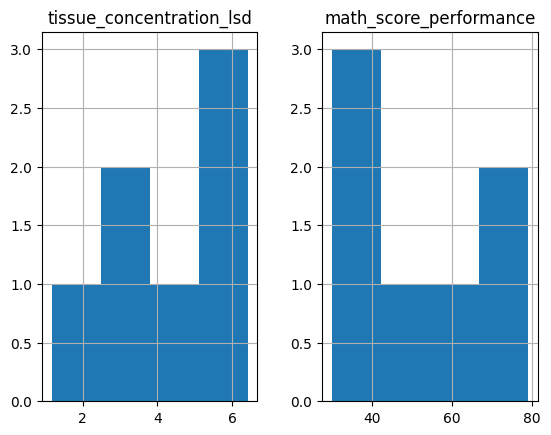

In [23]:
df_lsd.hist(bins=4)
plt.show()

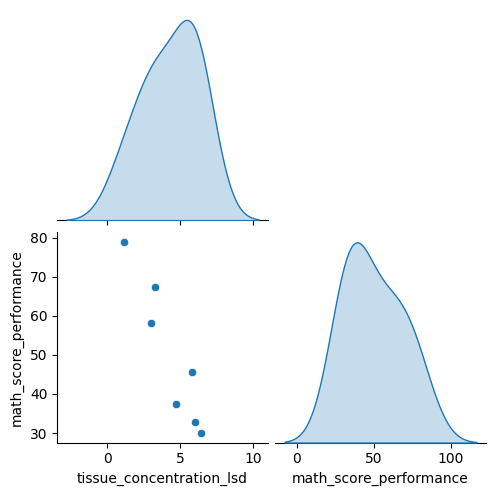

In [25]:
sns.pairplot(df_lsd, corner=True, diag_kind='kde')
plt.show()

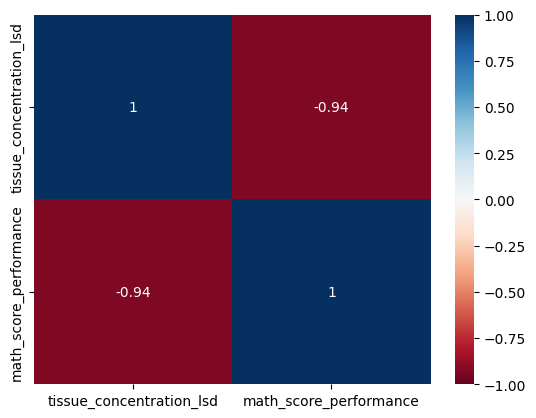

In [27]:
sns.heatmap(data=df_lsd.corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True)
plt.show()

$\hat{y} = Xβ+Ε$  
Closed form: $\beta = {(X^t X)}^{-1} X^t y  $  

In [39]:
X_des = df_lsd[['tissue_concentration_lsd']]
X_des.insert(0,'intercept', 1)
X_des = X_des.values
y = df_lsd[['math_score_performance']]
np.matmul(np.matmul(np.linalg.inv(np.matmul(X_des.T, X_des)), X_des.T), y.values)

array([[89.12387377],
       [-9.00946642]])

In [40]:
import statsmodels.api as sm

In [41]:
X = df_lsd['tissue_concentration_lsd']
X_design = sm.add_constant(X)
y = df_lsd['math_score_performance']
model = sm.OLS(y, X_design).fit()
model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     math_score_performance   R-squared:                       0.878
Model:                                OLS   Adj. R-squared:                  0.853
Method:                     Least Squares   F-statistic:                     35.93
Date:                    Tue, 16 Sep 2025   Prob (F-statistic):            0.00185
Time:                            02:00:11   Log-Likelihood:                -22.501
No. Observations:                       7   AIC:                             49.00
Df Residuals:                           5   BIC:                             48.89
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       89.1239      7.048     12.646      0.000      71.008     107.240
tissue_concentration_lsd    -9.0095      1.503     -5.994      0.002     -12.873      -5.146
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   3.627
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.334
Skew:                           0.187   Prob(JB):                        0.846
Kurtosis:                       1.997   Cond. No.                         12.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

$D: 7*2$ Data set inicial  
$D_{train}: 7*2$ Data set de aprendizaje  
$y_{train}: 7*1$ Vector de resultantes(objetivo)  

Predictors numeric: tissue_concentration_lsd
Predictors binary: 0  
Predictors_category: 0
Total predictors pipeline: 0




In [4]:
X_train = df_lsd[['tissue_concentration_lsd']] #debe ser DF
y_train = df_lsd['math_score_performance'] #debe ser vector

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [7]:
linear_model.intercept_

np.float64(89.12387376799305)

In [8]:
linear_model.coef_

array([-9.00946642])

In [20]:
my_value= pd.DataFrame({
    'tissue_concentration_lsd':[7]
})
linear_model.predict(my_value)

array([26.05760886])

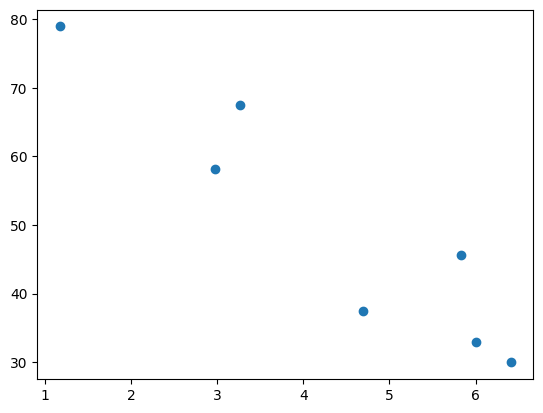

In [17]:
plt.scatter(x=X_train, y=)
plt.show()